A complete decision tree pipeline on a real dataset:

Load real data
Train/test split (avoid overfitting)
Train a basic decision tree
Visualize the tree (the BEST part of decision trees)
Evaluate properly (confusion matrix, classification report)
Tune hyperparameters (max_depth, min_samples_split, etc.)
Compare with Random Forest (a small preview of ensembles)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Convert to DataFrame for easy viewing
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = [iris.target_names[t] for t in y]

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nClass distribution:")
print(df['species'].value_counts())

Shape: (150, 5)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


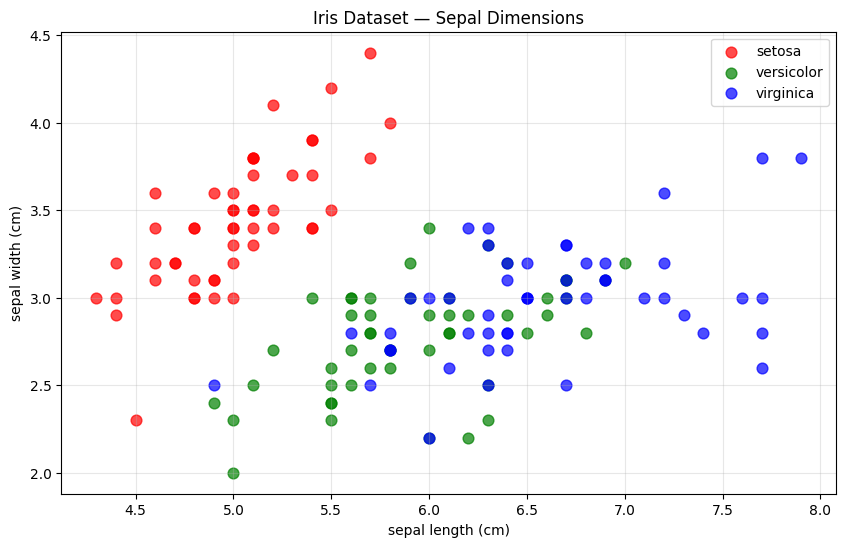

In [5]:
# Scatter plot to see the species
plt.figure(figsize=(10, 6))
colors = ['red', 'green', 'blue']
for i, species_name in enumerate(iris.target_names):
    mask = y == i
    plt.scatter(X[mask, 0], X[mask, 1], 
                color=colors[i], label=species_name, s=60, alpha=0.7)

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('Iris Dataset — Sepal Dimensions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,        # 30% goes to test set
    random_state=42,      # For reproducibility (your results match mine)
    stratify=y            # Keeps class distribution balanced in both sets
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size:     {X_test.shape[0]} samples")
print(f"\nTraining class distribution: {np.bincount(y_train)}")
print(f"Test class distribution:     {np.bincount(y_test)}")

Training set size: 105 samples
Test set size:     45 samples

Training class distribution: [35 35 35]
Test class distribution:     [15 15 15]


In [15]:
# Initialize the model
tree = DecisionTreeClassifier(
    criterion='gini',      # 'gini' or 'entropy' — understand both!
    max_depth=None,        # Let the tree grow fully (will tune this later)
    random_state=42
)

tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)

train_accuracy = tree.score(X_train, y_train)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Test accuracy:     {test_accuracy*100:.2f}%")

Training accuracy: 100.00%
Test accuracy:     93.33%


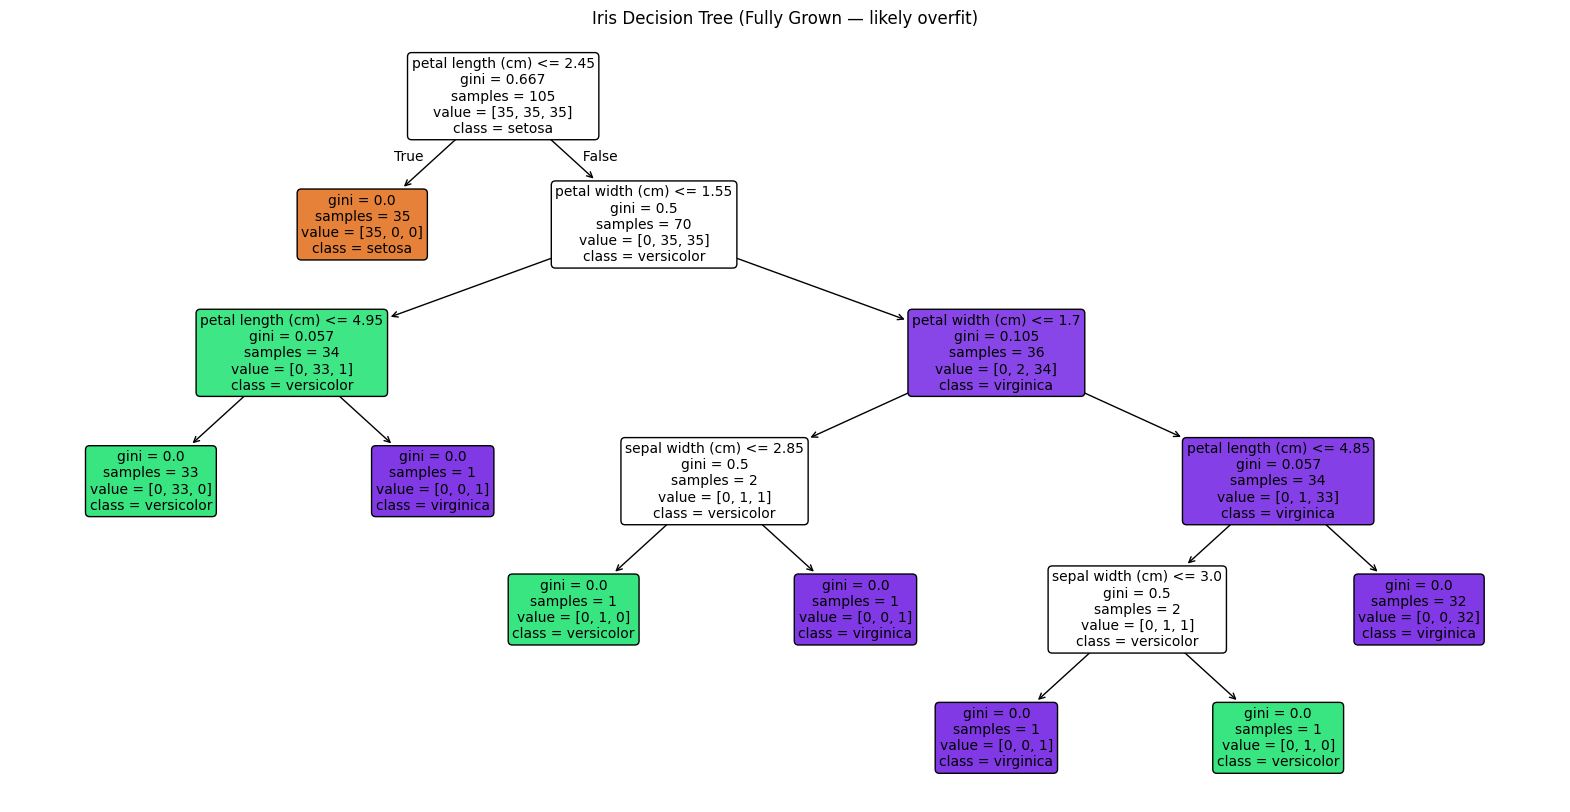

In [8]:
plt.figure(figsize=(20, 10))
plot_tree(tree,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,           # Color-code nodes by class
          rounded=True,
          fontsize=10)
plt.title('Iris Decision Tree (Fully Grown — likely overfit)')
plt.show()

Confusion Matrix:
[[15  0  0]
 [ 0 12  3]
 [ 0  0 15]]


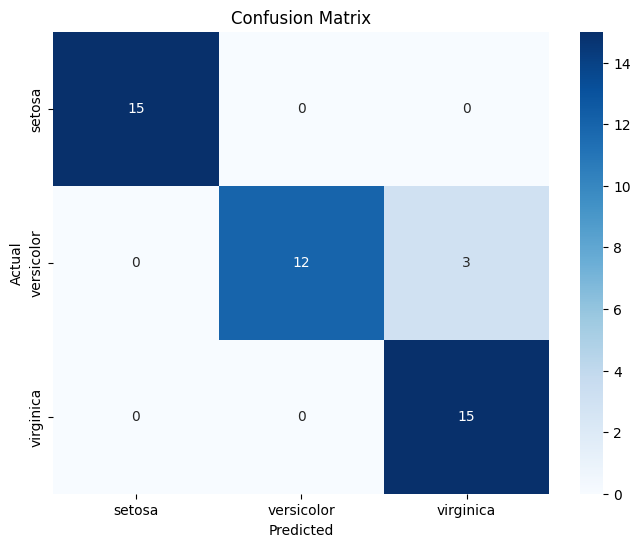


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



In [10]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Visualize confusion matrix
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification report (precision, recall, F1 for each class)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

   max_depth  train_acc  test_acc
0        1.0   0.666667  0.666667
1        2.0   0.971429  0.888889
2        3.0   0.980952  0.977778
3        4.0   0.990476  0.888889
4        5.0   1.000000  0.933333
5       10.0   1.000000  0.933333
6        NaN   1.000000  0.933333


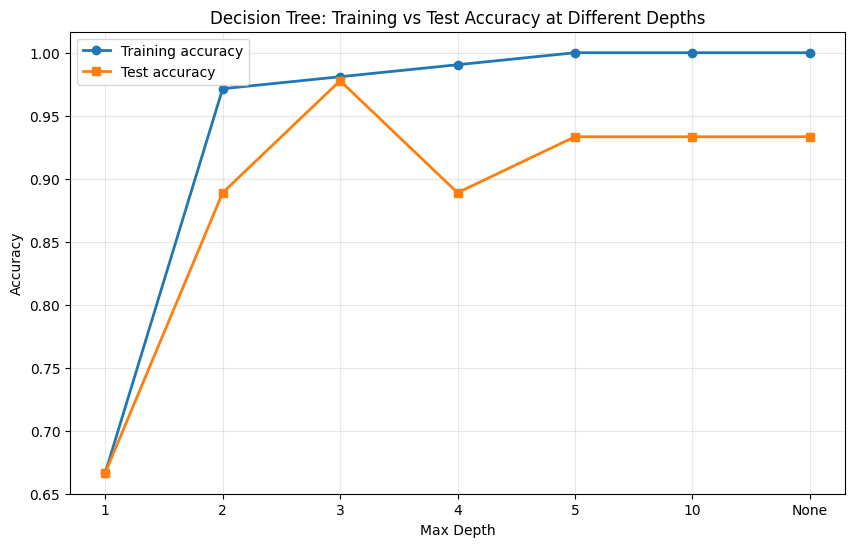

In [11]:
# Try different max_depth values
depths = [1, 2, 3, 4, 5, 10, None]
results = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_acc = tree.score(X_train, y_train)
    test_acc = tree.score(X_test, y_test)
    results.append({'max_depth': d, 'train_acc': train_acc, 'test_acc': test_acc})

# Display as table
results_df = pd.DataFrame(results)
print(results_df)

# Plot
plt.figure(figsize=(10, 6))
plt.plot([str(d) for d in depths], results_df['train_acc'], 'o-', label='Training accuracy', linewidth=2)
plt.plot([str(d) for d in depths], results_df['test_acc'], 's-', label='Test accuracy', linewidth=2)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Training vs Test Accuracy at Different Depths')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Final test accuracy: 97.78%


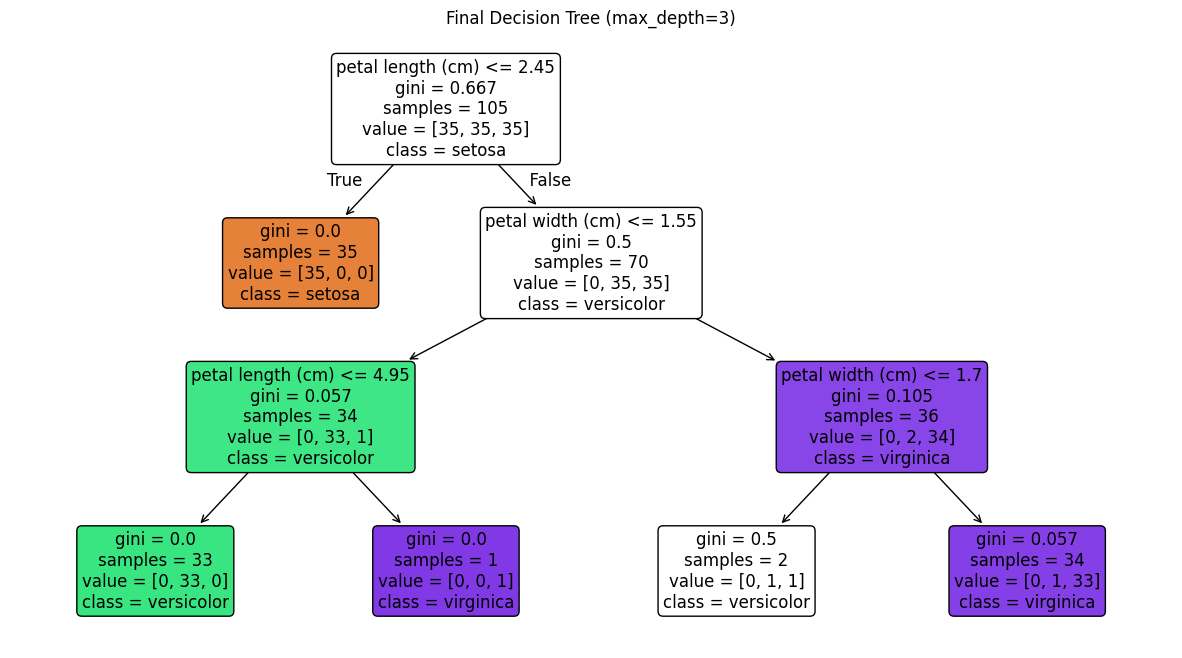


Feature Importance:
             feature  importance
2  petal length (cm)    0.550877
3   petal width (cm)    0.449123
1   sepal width (cm)    0.000000
0  sepal length (cm)    0.000000


In [12]:
# Train with optimal hyperparameters
final_tree = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
final_tree.fit(X_train, y_train)

print(f"Final test accuracy: {final_tree.score(X_test, y_test)*100:.2f}%")

# Visualize the FINAL (constrained, cleaner) tree
plt.figure(figsize=(15, 8))
plot_tree(final_tree,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=12)
plt.title('Final Decision Tree (max_depth=3)')
plt.show()

# Feature importance
print("\nFeature Importance:")
importances = pd.DataFrame({
    'feature': iris.feature_names,
    'importance': final_tree.feature_importances_
}).sort_values('importance', ascending=False)
print(importances)

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Train random forest
rf = RandomForestClassifier(
    n_estimators=100,     # 100 trees
    max_depth=3,
    random_state=42
)
rf.fit(X_train, y_train)

print(f"Decision Tree test accuracy: {final_tree.score(X_test, y_test)*100:.2f}%")
print(f"Random Forest test accuracy: {rf.score(X_test, y_test)*100:.2f}%")

Decision Tree test accuracy: 97.78%
Random Forest test accuracy: 91.11%
